# Strategic Audit of the PCV Program in Guatemala  
### Fourth Notebook: Exploratory Machine Learning and Pattern Detection

This notebook builds on the reconstructed analytical framework and interpretative analysis developed in the previous stages of the audit. While earlier notebooks focused on structuring fragmented program information, validating proxy indicators, and identifying descriptive patterns across the program architecture, this stage introduces exploratory machine learning techniques to further investigate latent structures and multidimensional relationships within the dataset.

Given the reconstructed and proxy-based nature of the data, the objective is not predictive modeling or causal inference, but rather the identification of organizational patterns, project profiles, and implementation dynamics across the PCV program. The analysis prioritizes interpretability and strategic insight generation over predictive performance.

The notebook combines unsupervised learning and interpretable supervised learning approaches to explore how operational intensity, contextual conditions, and project characteristics relate to transformation and adoption dynamics within the program ecosystem.

Overall, this notebook represents the transition from descriptive analysis toward exploratory analytical modeling in support of strategic decision-making within low-data international development contexts.

**Author:** J-F Jutras  
**Date:** May 2026  
**Dataset:** SUCO PCV Program Data (Guatemala)

## 4.1-Data Loading and Overview

In [1]:
import pandas as pd
import sys
import warnings

# Suppress openpyxl warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

# File path (Kaggle dataset)
file_path = "/kaggle/input/datasets/jfjutras07/pcv-guatemala-dataset-cleaned/pcv_guatemala_project_dataset.csv"

# Load dataset
df = pd.read_csv(file_path)

# Define path for PCV_Guatelmala_Dataset
PCV_path = "/kaggle/input/datasets/jfjutras07/pcv-guatemala-dataset/"

# Load all tables
df_capacidades = pd.read_excel(PCV_path + "Tabla_capacidades.xlsx")
df_componentes = pd.read_excel(PCV_path + "Tabla_componentes.xlsx")
df_cooperantes = pd.read_excel(PCV_path + "Tabla_cooperantes.xlsx")
df_entregables = pd.read_excel(PCV_path + "Tabla_entregables.xlsx")
df_mandatos = pd.read_excel(PCV_path + "Tabla_mandatos.xlsx")
df_proyectos = pd.read_excel(PCV_path + "Tabla_proyectos.xlsx")
df_socios = pd.read_excel(PCV_path + "Tabla_socios.xlsx")

# Standardize column names
df.columns = df.columns.str.lower()

df_mandatos.columns = df_mandatos.columns.str.lower()
df_cooperantes.columns = df_cooperantes.columns.str.lower()
df_socios.columns = df_socios.columns.str.lower()
df_proyectos.columns = df_proyectos.columns.str.lower()
df_entregables.columns = df_entregables.columns.str.lower()

# Load custom library from GitHub
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

# Add to Python path
sys.path.append("/kaggle/working/jfj-utils")

#Quick check
df.head()

Cloning into 'jfj-utils'...
remote: Enumerating objects: 3527, done.
remote: Counting objects: 100% (300/300), done.
remote: Compressing objects: 100% (192/192), done.
remote: Total 3527 (delta 244), reused 108 (delta 108), pack-reused 3227 (from 4)
Receiving objects: 100% (3527/3527), 1.18 MiB | 2.97 MiB/s, done.
Resolving deltas: 100% (2322/2322), done.


,id_proyecto,id_componente,titulo_proyecto,tipo_proyecto,complejidad_promedio,complejidad_total,clasificación,duración estimada en meses,calidad,sostenibilidad,...,i_transformation,i_resultados,i_contexto,i_riesgo,nb_entregables,id_capacitad,titulo_componente,familia_capacidades,production_density,project_type
0,1,3,Política de género (TPS),"Plan, estrategía o política",2.68,16.1,Proyecto complejo y exigente,5,4,3,...,3.5,3.0,2.5,4.5,6,1,Política y protocolos integrales de género (sa...,Derecho de las mujeres e igualdad entre las mu...,1.20,Proyecto de beneficiarios (servicios externos)
1,2,3,Política de género (AGIMS),"Plan, estrategía o política",2.73,16.4,Proyecto complejo y exigente,5,4,4,...,3.5,3.0,3.5,4.5,6,1,Política y protocolos integrales de género (sa...,Derecho de las mujeres e igualdad entre las mu...,1.20,Proyecto de beneficiarios (servicios externos)
2,3,5,Herramientas de seguridad y salvaguardia,Herramientas,2.53,10.1,Proyecto complejo y exigente,4,3,2,...,2.5,2.0,2.0,4.0,4,1,Caja de herramientas - género,Derecho de las mujeres e igualdad entre las mu...,1.00,Proyecto de desempeño (servicios internos)
3,4,6,Capacitación sobre la política de género,Capacitación y transferencia de conocimientos,2.10,2.1,Proyecto ligero,4,3,2,...,3.0,4.0,3.0,4.5,1,1,Fortalecimiento de conocimientos y competencia...,Derecho de las mujeres e igualdad entre las mu...,0.25,Proyecto de beneficiarios (servicios externos)
4,5,6,Capacitación - mujeres y seguridad alimentaria,Capacitación y transferencia de conocimientos,3.30,3.3,Proyecto especializado,2,3,3,...,2.5,3.0,2.5,3.5,1,1,Fortalecimiento de conocimientos y competencia...,Derecho de las mujeres e igualdad entre las mu...,0.50,Proyecto de incidencia (impacto externo)


## 4.2-Data Selection and Transformation

**Feature Selection**

This notebook focuses on exploratory machine learning analysis using the reconstructed project-level dataset developed in the previous stages. The objective is to identify latent implementation patterns, operational profiles, and multidimensional relationships across projects while preserving the interpretative and proxy-based nature of the analytical framework.

| Variable Group                                        | Variables                                                                             | Analytical Role                                                                                                 |
| ----------------------------------------------------- | ------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------- |
| Structural Typology                                   | `project_type`, `clasificación`                                                       | Core intervention logic and operational intensity structure of projects                                         |
| Operational Intensity                                 | `duración estimada en meses`, `production_density`, `complejidad_promedio`            | Measures workload, delivery density, and operational/technical complexity                                       |
| Quality & Organizational Dynamics                     | `calidad`, `i_adopcion`, `i_transformation`, `i_resultados`, `i_contexto`, `i_riesgo` | Composite indices capturing implementation quality, organizational uptake, outcomes, context, and risk dynamics |


In [2]:
# Clean exploratory dataset

features = df[[
    # Structural typology
    "project_type",
    "clasificación",

    # Operational intensity
    "duración estimada en meses",
    "production_density",
    "complejidad_promedio",

    # Composite indices
    "calidad",
    "i_adopcion",
    "i_transformation",
    "i_resultados",
    "i_contexto",
    "i_riesgo"
]].copy()

features.head()

,project_type,clasificación,duración estimada en meses,production_density,complejidad_promedio,calidad,i_adopcion,i_transformation,i_resultados,i_contexto,i_riesgo
0,Proyecto de beneficiarios (servicios externos),Proyecto complejo y exigente,5,1.20,2.68,4,3.75,3.5,3.0,2.5,4.5
1,Proyecto de beneficiarios (servicios externos),Proyecto complejo y exigente,5,1.20,2.73,4,4.00,3.5,3.0,3.5,4.5
2,Proyecto de desempeño (servicios internos),Proyecto complejo y exigente,4,1.00,2.53,3,2.75,2.5,2.0,2.0,4.0
3,Proyecto de beneficiarios (servicios externos),Proyecto ligero,4,0.25,2.10,3,3.25,3.0,4.0,3.0,4.5
4,Proyecto de incidencia (impacto externo),Proyecto especializado,2,0.50,3.30,3,3.00,2.5,3.0,2.5,3.5


**Encoding and Scaling**

In [3]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

cat_cols = [
    "project_type",
    "clasificación"
]

num_cols = [
    "duración estimada en meses",
    "production_density",
    "complejidad_promedio",
    "calidad",
    "i_adopcion",
    "i_transformation",
    "i_resultados",
    "i_contexto",
    "i_riesgo"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

X_processed = preprocessor.fit_transform(features)

X_processed.shape

(32, 16)

The preprocessing pipeline has successfully transformed the dataset into a compact matrix while preserving the original project-level structure. The number of rows confirms that no aggregation mismatch or data loss occurred during encoding, while the 16 resulting features reflect a controlled expansion of categorical variables combined with standardized numerical indicators. 

Given the small sample size, this dimensionality remains appropriate and avoids excessive sparsity. Overall, the dataset is now structurally consistent and ready for downstream exploratory analytical tasks such as clustering.

## 4.3-Exploratory Clustering Analysis

This section introduces unsupervised clustering techniques to explore latent implementation patterns within the reconstructed PCV project portfolio. Rather than relying on predefined outcomes or performance assumptions, the analysis seeks to identify naturally emerging project groupings based on operational intensity, strategic configuration, and multidimensional implementation dynamics.

Because the program combines multiple project taxonomies, clustering is conducted through two separate analytical configurations instead of a single unified model. The first focuses on strategic classifications and operational complexity, while the second examines functional project types and intervention logic. Both configurations integrate operational variables and composite indices to capture multidimensional implementation behavior.

**Strategic Classification Configuration**

In [4]:
# Strategic Classification Configuration
features_strategic = df[[

    # Strategic classification
    "clasificación",

    # Operational intensity
    "duración estimada en meses",
    "production_density",
    "complejidad_promedio",

    # Composite indices
    "calidad",
    "i_adopcion",
    "i_transformation",
    "i_resultados",
    "i_contexto",
    "i_riesgo"

]].copy()

# Encoding and Scaling
cat_cols_strategic = ["clasificación"]

num_cols_strategic = [

    "duración estimada en meses",
    "production_density",
    "complejidad_promedio",

    "calidad",
    "i_adopcion",
    "i_transformation",
    "i_resultados",
    "i_contexto",
    "i_riesgo"
]

preprocessor_strategic = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_strategic),
        ("num", StandardScaler(), num_cols_strategic)
    ]
)

X_strategic = preprocessor_strategic.fit_transform(features_strategic)

X_strategic.shape

(32, 13)

In [5]:
#Convert into DataFrame (Strategic)
X_strategic_df = pd.DataFrame(
    X_strategic,
    columns=preprocessor_strategic.get_feature_names_out()
)

from modeling.clustering_models import compare_clustering_models
models = compare_clustering_models(
    df=X_strategic_df,
    predictors=X_strategic_df.columns.tolist(),
    k=4,
    optimize=True
)

Starting Clustering Comparison | Predictors: 13
---------------------------------------------

--- Final Clustering Comparison (Sorted by Silhouette) ---


,Model,Clusters,Silhouette
0,Agglomerative,2,0.2368
1,BIRCH,2,0.2368
4,KMeans,2,0.2368
3,GMM,6,0.1030
2,DBSCAN,0,0.0000


Agglomerative Clustering was retained for the final exploratory analysis because it achieved one of the strongest internal validity scores while offering higher interpretability for small organizational datasets.


--- Clustering Performance Check ---
Model                     : Agglomerative Clustering - Strategic Configuration
Number of Clusters         : 2
Silhouette Score           : 0.2077  (Goal: -> 1.0)
Calinski-Harabasz Index    : 10.18 (Goal: High)
Davies-Bouldin Index       : 1.4414  (Goal: -> 0.0)
---------------------------------------------
Status: WEAK. Poorly defined clusters; high risk of overlap.
---------------------------------------------


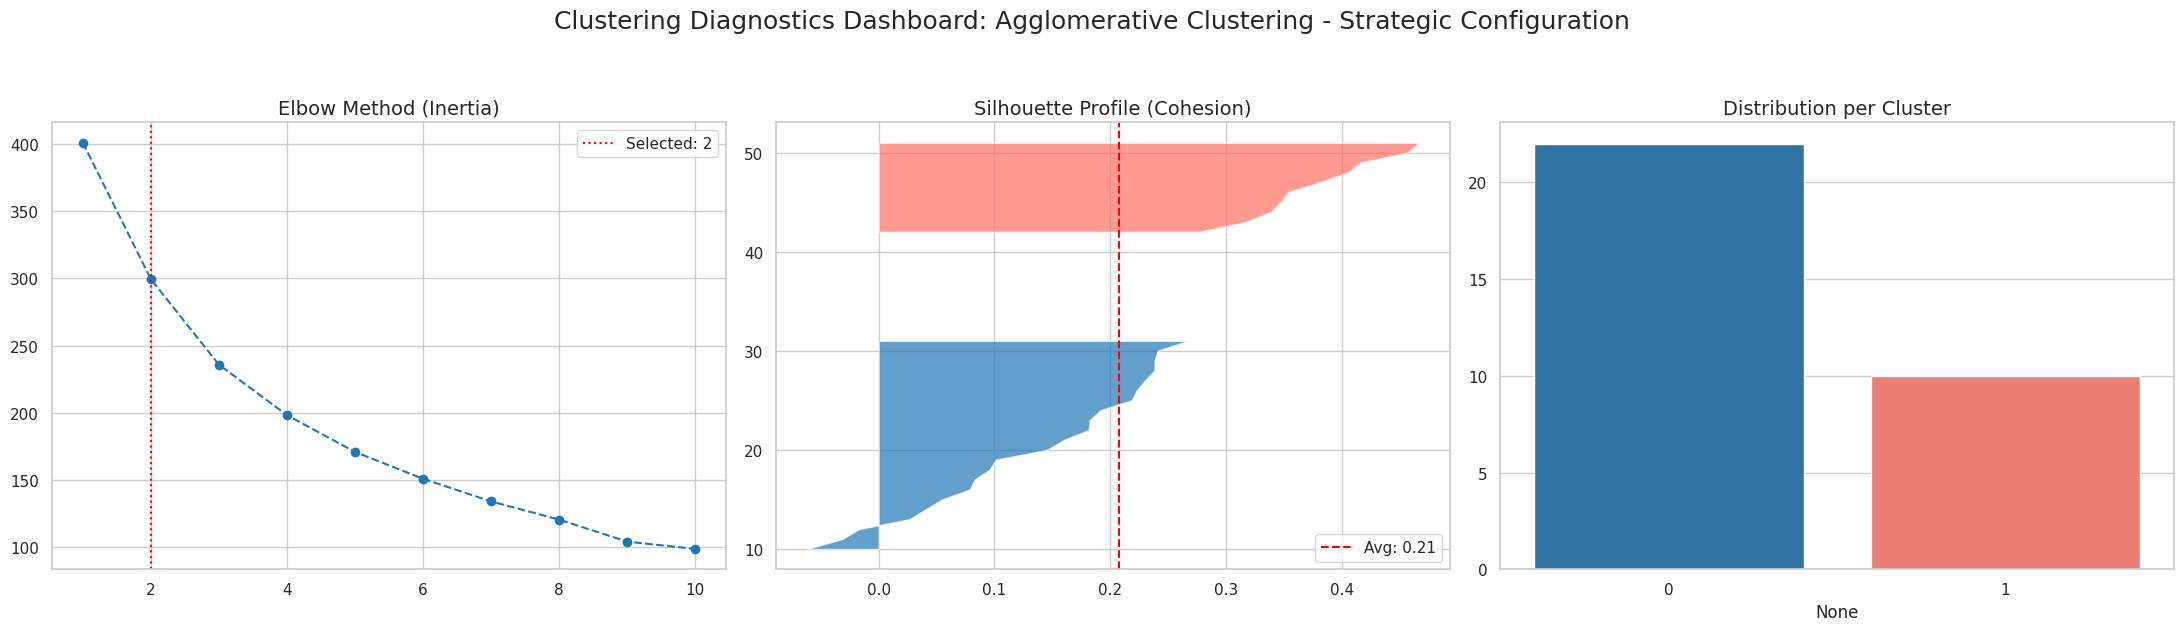

{'silhouette': np.float64(0.20770390902013477),
 'calinski_harabasz': np.float64(10.177906019898774),
 'davies_bouldin': np.float64(1.441368722886758),
 'n_clusters': 2}

In [6]:
from visualization.explore_clusters import plot_cluster_diagnostics
from sklearn.cluster import AgglomerativeClustering

# Model configuration
agglo_model = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

# Generate cluster labels
labels_agglo = agglo_model.fit_predict(X_strategic_df)

# Diagnostic dashboard
cluster_metrics = plot_cluster_diagnostics(
    df_scaled=X_strategic_df,
    labels=labels_agglo,
    model_name="Agglomerative Clustering - Strategic Configuration"
)

cluster_metrics

Cluster separation remains moderate, suggesting that projects share overlapping implementation characteristics rather than forming rigid operational categories. This reflects the structurally hybrid nature of the reconstructed program portfolio.

In [7]:
# Add cluster labels to original dataframe
df["cluster_strategic"] = labels_agglo

# Cluster profile
cluster_profile = df.groupby("cluster_strategic")[[
    "duración estimada en meses",
    "production_density",
    "complejidad_promedio",
    "calidad",
    "i_adopcion",
    "i_transformation",
    "i_resultados",
    "i_contexto",
    "i_riesgo"
]].mean().round(2)

cluster_profile

,duración estimada en meses,production_density,complejidad_promedio,calidad,i_adopcion,i_transformation,i_resultados,i_contexto,i_riesgo
cluster_strategic,,,,,,,,,
0,4.82,1.03,2.49,3.23,3.34,3.11,3.27,2.48,4.16
1,2.00,1.99,2.48,3.30,3.02,2.40,2.45,2.80,4.45


Two broad project archetypes emerge from the clustering analysis. The first cluster is characterized by longer and more institutionally embedded projects associated with stronger adoption and transformation dynamics. The second cluster groups shorter and high-density interventions that appear more operationally intensive but generate comparatively lower organizational transformation and results.

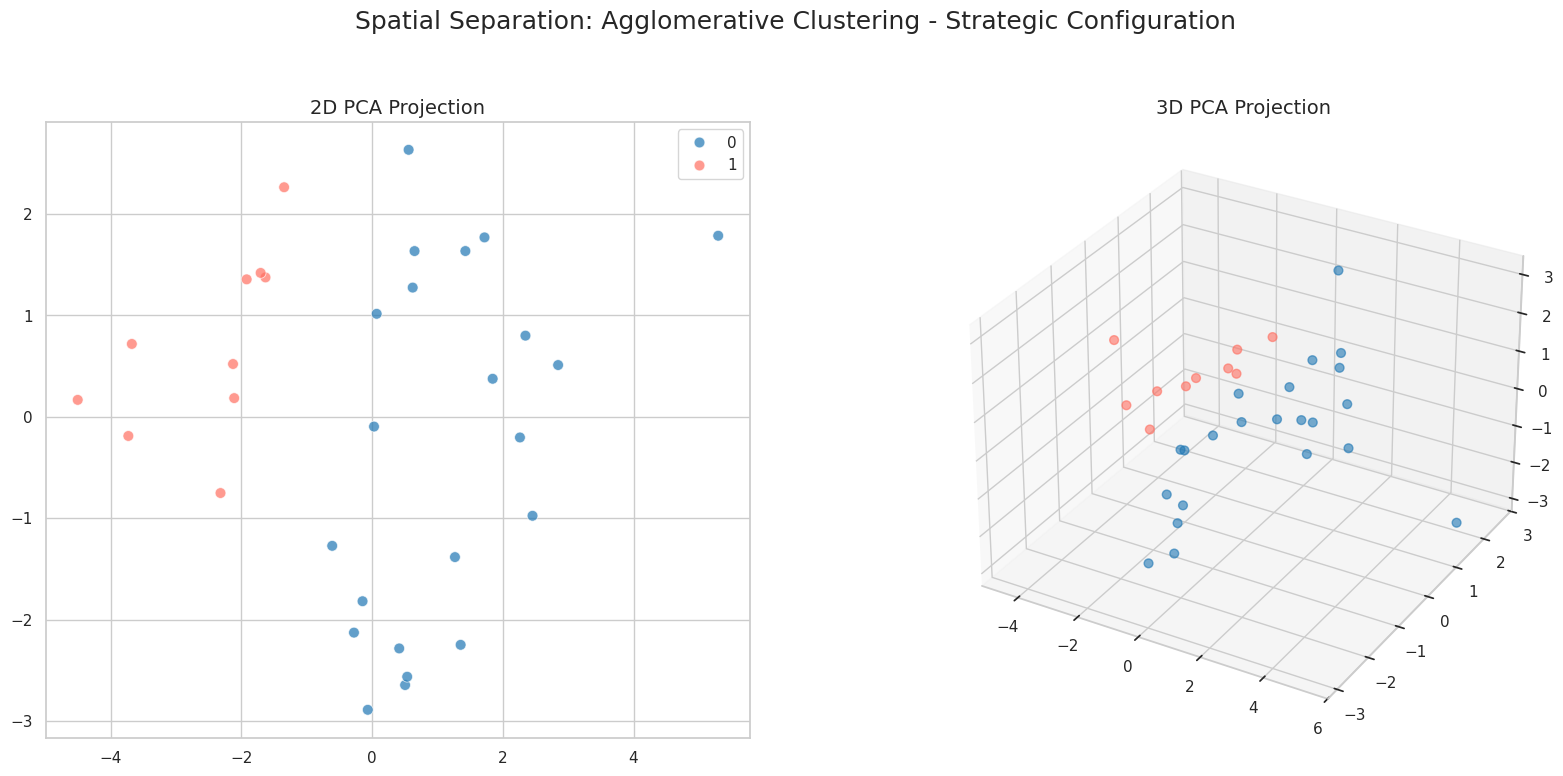

In [8]:
from visualization.explore_clusters import plot_cluster_projections, plot_cluster_radar_charts

#Cluster projections - Strategic
plot_cluster_projections(
    df_scaled=X_strategic_df,
    labels=labels_agglo,
    model_name="Agglomerative Clustering - Strategic Configuration"
)

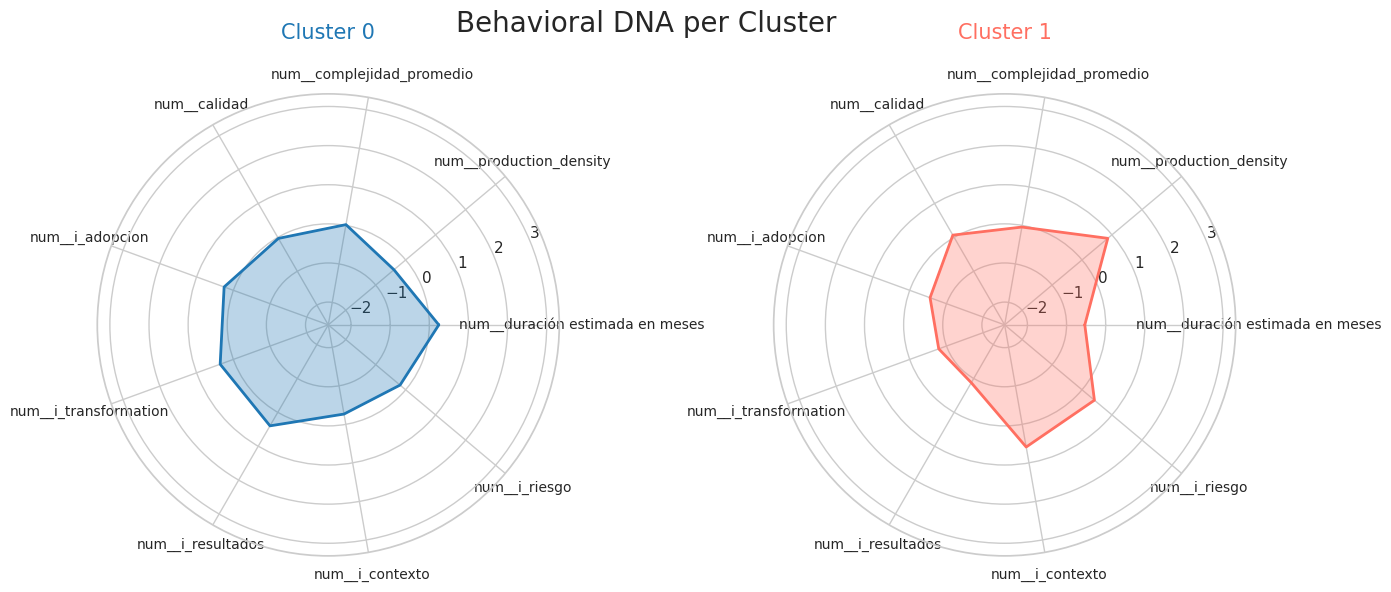

In [9]:
radar_features = [
    "num__duración estimada en meses",
    "num__production_density",
    "num__complejidad_promedio",
    "num__calidad",
    "num__i_adopcion",
    "num__i_transformation",
    "num__i_resultados",
    "num__i_contexto",
    "num__i_riesgo"
]

plot_cluster_radar_charts(
    df_scaled=X_strategic_df,
    labels=labels_agglo,
    feature_names=radar_features
)

**Functional Project-Type Configuration**

In [10]:
# Functional Classification Configuration
features_functional = df[[

    # Functional classification
    "project_type",

    # Operational intensity
    "duración estimada en meses",
    "production_density",
    "complejidad_promedio",

    # Composite indices
    "calidad",
    "i_adopcion",
    "i_transformation",
    "i_resultados",
    "i_contexto",
    "i_riesgo"

]].copy()

cat_cols_functional = ["project_type"]

num_cols_functional = [
    "duración estimada en meses",
    "production_density",
    "complejidad_promedio",
    "calidad",
    "i_adopcion",
    "i_transformation",
    "i_resultados",
    "i_contexto",
    "i_riesgo"
]

preprocessor_functional = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_functional),
        ("num", StandardScaler(), num_cols_functional)
    ]
)

X_functional = preprocessor_functional.fit_transform(features_functional)

X_functional.shape

(32, 12)

In [11]:
# Convert into DataFrame (functional)
X_functional_df = pd.DataFrame(
    X_functional,
    columns=preprocessor_functional.get_feature_names_out()
)

from modeling.clustering_models import compare_clustering_models

models_functional = compare_clustering_models(
    df=X_functional_df,
    predictors=X_functional_df.columns.tolist(),
    k=4,
    optimize=True
)

Starting Clustering Comparison | Predictors: 12
---------------------------------------------

--- Final Clustering Comparison (Sorted by Silhouette) ---


,Model,Clusters,Silhouette
0,Agglomerative,2,0.2390
1,BIRCH,2,0.2390
4,KMeans,5,0.1823
3,GMM,5,0.1121
2,DBSCAN,0,0.0000



--- Clustering Performance Check ---
Model                     : Agglomerative Clustering - Functional Configuration
Number of Clusters         : 2
Silhouette Score           : 0.2603  (Goal: -> 1.0)
Calinski-Harabasz Index    : 13.14 (Goal: High)
Davies-Bouldin Index       : 1.4422  (Goal: -> 0.0)
---------------------------------------------
Status: ACCEPTABLE. Moderate structure detected; some overlap likely.
---------------------------------------------


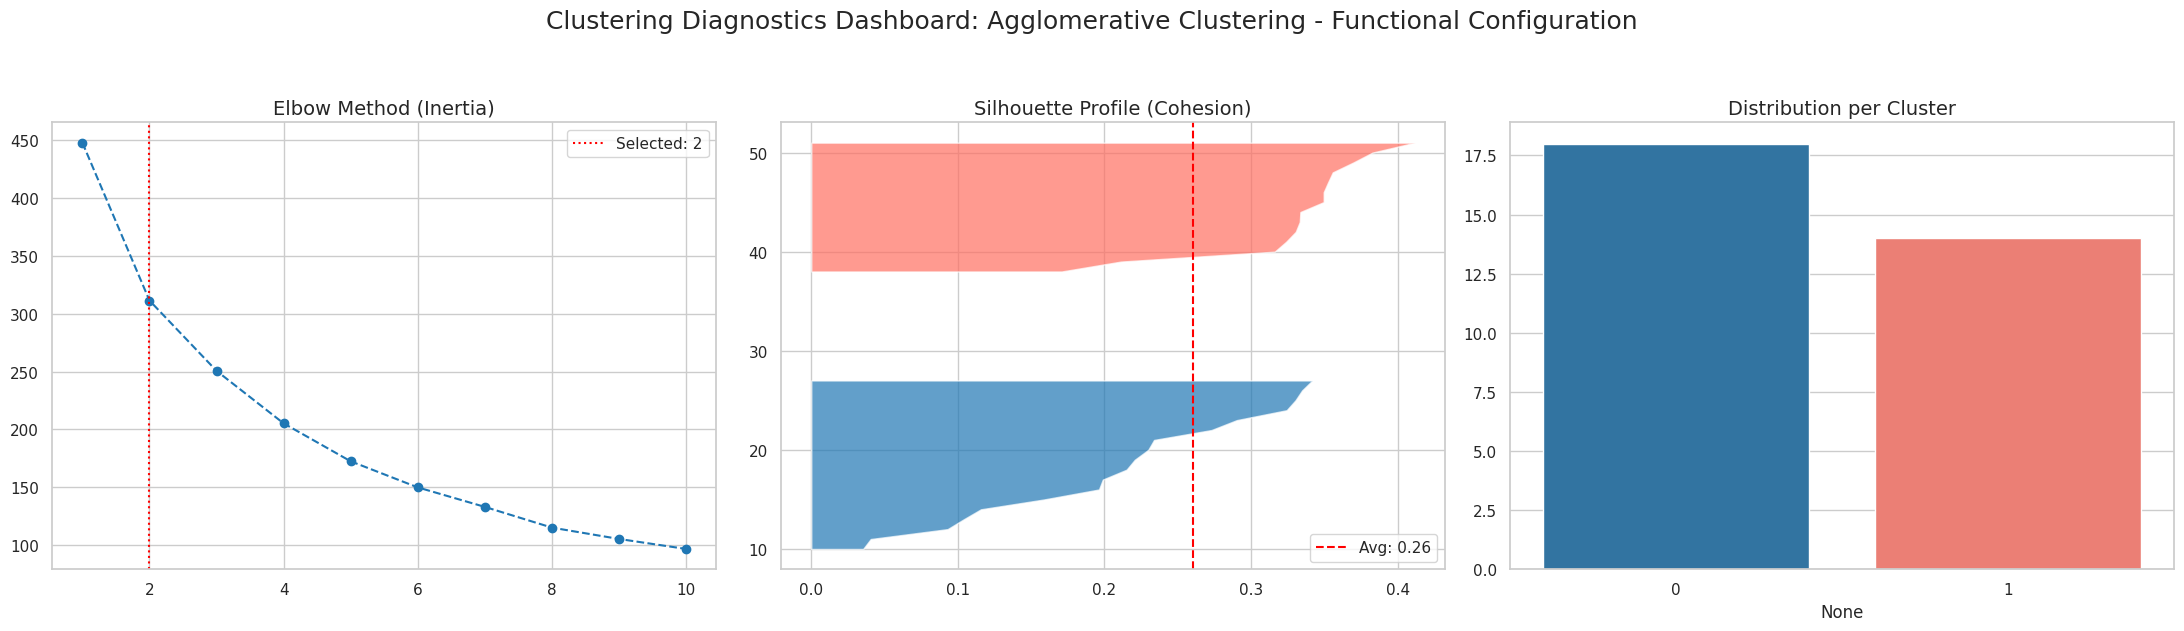

{'silhouette': np.float64(0.2602927019235137),
 'calinski_harabasz': np.float64(13.135775201706425),
 'davies_bouldin': np.float64(1.4422286272521805),
 'n_clusters': 2}

In [12]:
# Model configuration
agglo_functional = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

# Generate cluster labels
labels_functional = agglo_functional.fit_predict(X_functional_df)

# Diagnostic dashboard
cluster_metrics_functional = plot_cluster_diagnostics(
    df_scaled=X_functional_df,
    labels=labels_functional,
    model_name="Agglomerative Clustering - Functional Configuration"
)

cluster_metrics_functional

Compared to the strategic configuration, the functional clustering model shows a clearer internal structure, suggesting that project formats and intervention logic contribute more strongly to the differentiation of implementation behaviors across the portfolio.

In [13]:
# Add functional cluster labels to original dataframe
df["cluster_functional"] = labels_functional

# Functional cluster profile
cluster_profile_functional = df.groupby("cluster_functional")[[
    "duración estimada en meses",
    "production_density",
    "complejidad_promedio",
    "calidad",
    "i_adopcion",
    "i_transformation",
    "i_resultados",
    "i_contexto",
    "i_riesgo"
]].mean().round(2)

cluster_profile_functional

,duración estimada en meses,production_density,complejidad_promedio,calidad,i_adopcion,i_transformation,i_resultados,i_contexto,i_riesgo
cluster_functional,,,,,,,,,
0,5.06,1.02,2.58,3.61,3.42,3.00,3.28,2.67,4.53
1,2.50,1.73,2.37,2.79,3.02,2.75,2.67,2.46,3.89


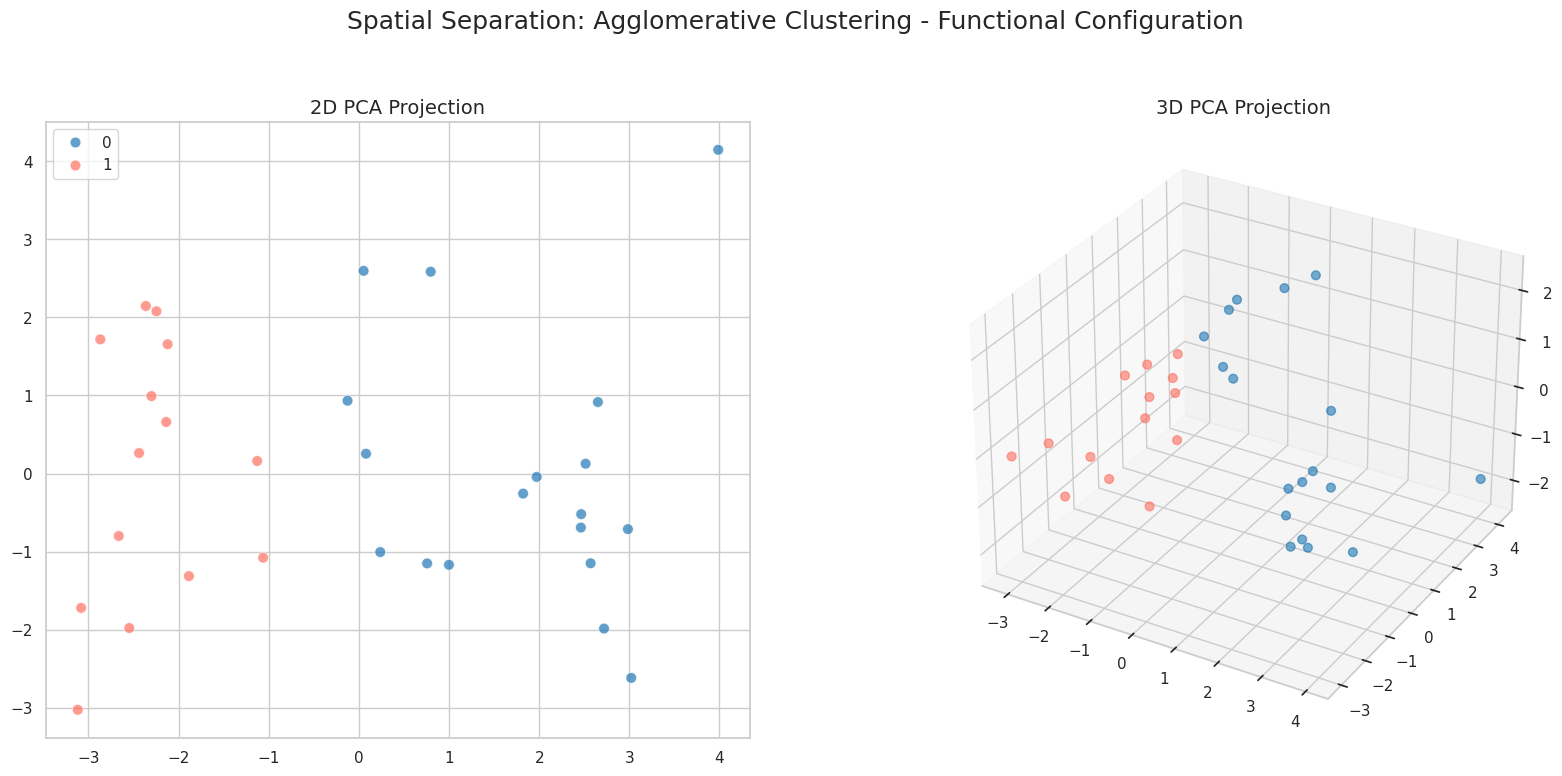

In [14]:
#Cluster projections - Functional
plot_cluster_projections(
    df_scaled=X_functional_df,
    labels=labels_functional,
    model_name="Agglomerative Clustering - Functional Configuration"
)

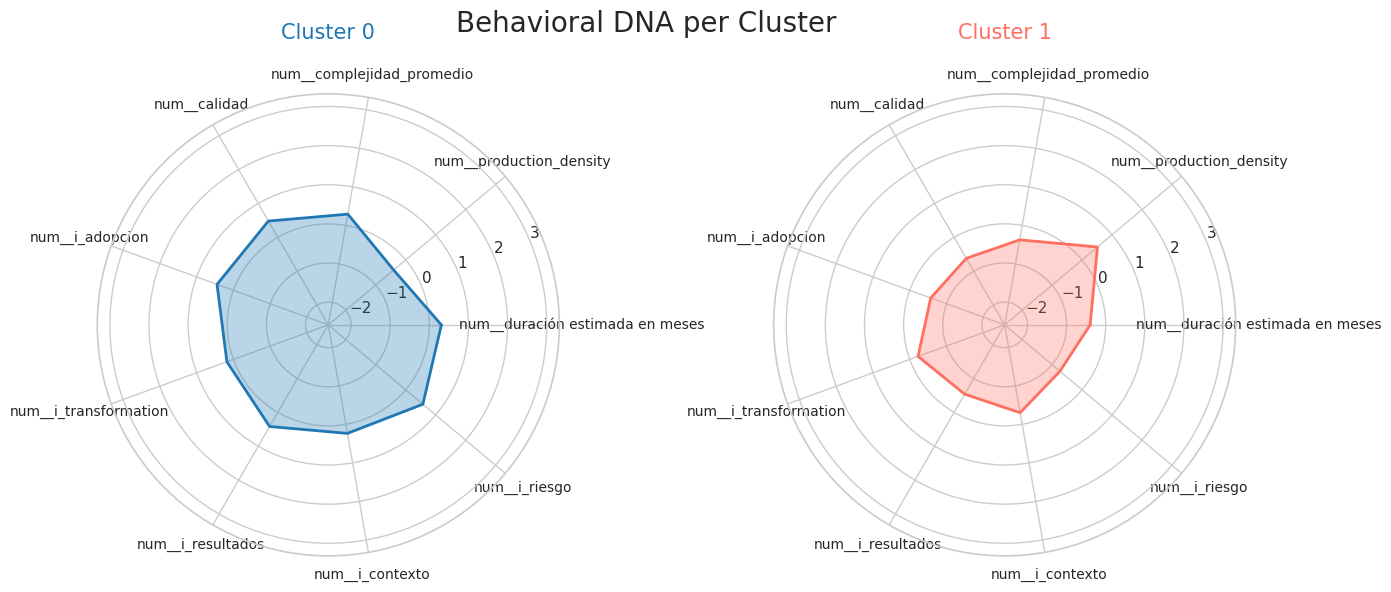

In [15]:
#Radar charts - Functional
plot_cluster_radar_charts(
    df_scaled=X_functional_df,
    labels=labels_functional,
    feature_names=radar_features
)

The functional clustering analysis reveals two distinct implementation archetypes within the PCV project portfolio, reflecting differences in how intervention formats structure operational behavior and performance outcomes.

**Cluster 0 — Structured / Systemic Interventions**

Cluster 0 groups projects that are longer in duration and more structurally embedded within the program. These interventions are characterized by higher quality scores and stronger performance across transformation and results dimensions, while operating with lower production density. Overall, this cluster reflects deeper, more strategic interventions focused on institutional integration and sustained organizational change rather than rapid delivery.

**Cluster 1 — Operational / High-Throughput Interventions**

Cluster 1 consists of shorter-duration, higher production density projects that are more execution-oriented. These interventions show comparatively lower scores in quality, results, and transformation, suggesting a focus on operational delivery and output generation rather than systemic change. This cluster reflects a more agile but less structurally transformative implementation logic within the portfolio.

In [16]:
for c in sorted(df["cluster_functional"].unique()):
    print(f"\nCluster {c}")
    print(df.loc[df["cluster_functional"] == c, "titulo_proyecto"].to_string(index=False))


Cluster 0
                         Política de género (TPS)
                       Política de género (AGIMS)
         Capacitación sobre la política de género
                            Capacitación - género
                    Análisis del maiz transgénico
                      Capacitación - agroecología
                       Política de medio ambiente
                    Capacitación - medio ambiente
          Herramienta de seguimiento de proyectos
              Matriz de priorización de proyectos
  Cápsulas de capacitación - gestión de proyectos
          Análisis estratégico - encuestas REDSAG
                                      Matriz RACI
                           Plan estrategico (TPS)
                        Plan estratégico (REDSAG)
Actualización del trifolio institucional (REDSAG)
                     Actualización PFC  (Oxlajuj)
         Capacitación - desarrollo organizacional

Cluster 1
          Herramientas de seguridad y salvaguardia
    Capacitación - mujeres 

The clustering results are broadly consistent in identifying two main implementation archetypes. Both configurations identify two overlapping implementation archetypes, with the functional structure showing slightly higher internal separation and interpretability.

## 4.4–Exploratory Feature Importance

**Cross-Dependency Matrix**

**This analysis is explicitly exploratory and should be interpreted with methodological caution.**

The dataset is reconstructed and proxy-based, and the sample size is limited (n = 32 projects). In this context, the objective is not statistical inference, causal identification, or predictive optimization. Instead, the following analysis uses a set of supervised learning models (Random Forest regressors) to explore latent structural dependencies between program indices.

The resulting outputs should therefore be understood as **model-based relational signals reflecting how variables jointly contribute to variance within a constrained multivariate system**

and not as:

- **causal relationships**
- **statistical correlations**
- **or stable external generalizations.**

In [17]:
from sklearn.ensemble import RandomForestRegressor

# Define system-level indices (organizational dimensions)
indices = [
    "calidad",
    "i_adopcion",
    "i_transformation",
    "i_resultados",
    "i_contexto",
    "i_riesgo"
]

# Initialize empty dependency matrix
# Rows = target variable
# Columns = explanatory variables
dependency_matrix = pd.DataFrame(
    index=indices,
    columns=indices,
    data=0.0
)

# Loop through each variable as target
for target in indices:
    
    # Define predictors (all other indices)
    X = df[indices].drop(columns=[target])
    y = df[target]
    
    # Initialize non-linear model (captures interactions + thresholds)
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )
    
    # Fit model
    model.fit(X, y)
    
    # Extract feature importance (model-based contribution to variance reduction)
    importances = model.feature_importances_
    
    # Store results in matrix (aligned with predictors)
    dependency_matrix.loc[target, X.columns] = importances

# Display raw dependency matrix
dependency_matrix

,calidad,i_adopcion,i_transformation,i_resultados,i_contexto,i_riesgo
calidad,0.000000,0.198720,0.186915,0.256293,0.093242,0.264830
i_adopcion,0.108421,0.000000,0.479791,0.177372,0.137423,0.096992
i_transformation,0.094970,0.357111,0.000000,0.331776,0.070612,0.145531
i_resultados,0.159012,0.264851,0.373310,0.000000,0.121037,0.081791
i_contexto,0.060665,0.410254,0.152984,0.112002,0.000000,0.264095
i_riesgo,0.260111,0.140010,0.270584,0.090699,0.238595,0.000000


This matrix is an exploratory dependency structure that reflects directional relationships between indices, based on how they interact within the reconstructed framework. Values indicate the relative strength of association from one dimension to another, without assuming symmetry or causality.

Overall, the structure is clearly non-symmetric, meaning each relationship depends on direction. The strongest patterns suggest that adoption (i_adopcion) is closely linked to transformation (0.48) and also strongly influenced by context (0.41). Similarly, transformation is strongly connected to results (0.33–0.37 range), indicating a logical progression from internal change to observable outcomes.

By contrast, quality (calidad) appears more diffuse, with moderate and balanced links across several dimensions rather than a dominant role. Risk (i_riesgo) shows relatively even connections across multiple indices, suggesting it behaves more like a structural condition than a direct driver.

In summary, the system shows a layered structure: context and adoption act as upstream conditions, transformation sits in the middle as a bridge variable, and results emerge downstream, while quality and risk function as broader modulators of the system rather than primary drivers.

**Adoption**

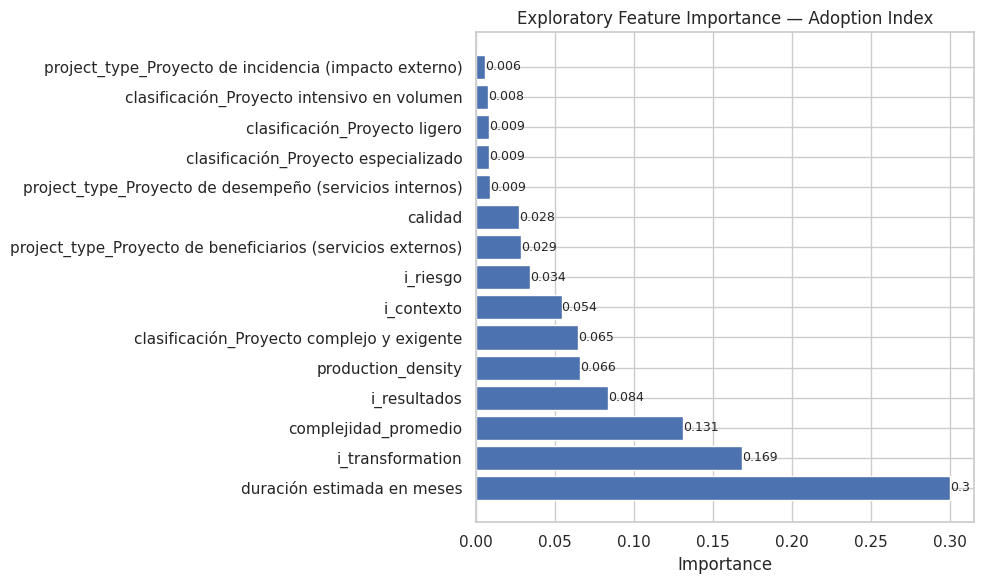

In [18]:
# Exploratory Feature Importance — Adoption Dynamics

from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Target
y_adoption = df["i_adopcion"]

# Features
X_adoption = df[[
    "project_type",
    "clasificación",
    "duración estimada en meses",
    "production_density",
    "complejidad_promedio",
    "calidad",
    "i_transformation",
    "i_resultados",
    "i_contexto",
    "i_riesgo"
]].copy()

# Columns
cat_cols = ["project_type", "clasificación"]

num_cols = [
    "duración estimada en meses",
    "production_density",
    "complejidad_promedio",
    "calidad",
    "i_transformation",
    "i_resultados",
    "i_contexto",
    "i_riesgo"
]

# Preprocessor
preprocessor_local = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

# Model
rf_adoption = Pipeline([
    ("preprocessor", preprocessor_local),
    ("rf", RandomForestRegressor(n_estimators=300, random_state=42))
])

# Fit
rf_adoption.fit(X_adoption, y_adoption)

# Feature names
encoded_features_adoption = rf_adoption.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(cat_cols)

all_features_adoption = list(encoded_features_adoption) + num_cols

# Importance table
importance_adoption = pd.DataFrame({
    "Feature": all_features_adoption,
    "Importance": rf_adoption.named_steps["rf"].feature_importances_
}).sort_values("Importance", ascending=True)

# Plot
plt.figure(figsize=(10,6))

bars = plt.barh(
    importance_adoption["Feature"],
    importance_adoption["Importance"]
)

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        round(bar.get_width(), 3),
        va="center",
        fontsize=9
    )

plt.title("Exploratory Feature Importance — Adoption Index")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

The exploratory feature importance analysis suggests that adoption dynamics within the PCV portfolio are driven primarily by operational and organizational factors rather than by formal project categories. Project duration emerged as the strongest contributor, followed by transformation capacity, operational complexity, and observed results. This indicates that longer and more structurally embedded interventions tend to generate stronger organizational appropriation. 

In contrast, formal project typologies and strategic classifications contribute relatively little to adoption variability, suggesting that implementation dynamics matter more than administrative project categories in shaping organizational uptake across the reconstructed program portfolio.

**Transformation**

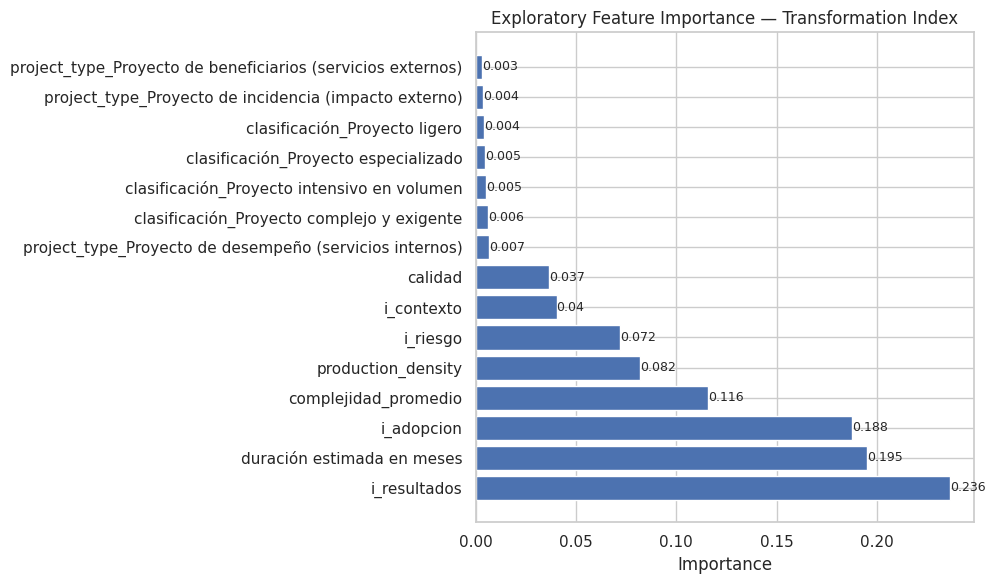

In [19]:
# Exploratory Feature Importance — Transformation Dynamics

# Target variable
y_transformation = df["i_transformation"]

# Predictors
X_transformation = df[[
    "project_type",
    "clasificación",
    "duración estimada en meses",
    "production_density",
    "complejidad_promedio",
    "calidad",
    "i_adopcion",
    "i_resultados",
    "i_contexto",
    "i_riesgo"
]].copy()

# Columns
cat_cols = ["project_type", "clasificación"]

num_cols_transformation = [
    "duración estimada en meses",
    "production_density",
    "complejidad_promedio",
    "calidad",
    "i_adopcion",
    "i_resultados",
    "i_contexto",
    "i_riesgo"
]

# Preprocessor
preprocessor_transformation = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols_transformation)
])

# Model
rf_transformation = Pipeline([
    ("preprocessor", preprocessor_transformation),
    ("rf", RandomForestRegressor(n_estimators=300, random_state=42))
])

# Fit
rf_transformation.fit(X_transformation, y_transformation)

# Feature names
encoded_features_transformation = rf_transformation.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(cat_cols)

all_features_transformation = list(encoded_features_transformation) + num_cols_transformation

# Importance table
importance_transformation = pd.DataFrame({
    "Feature": all_features_transformation,
    "Importance": rf_transformation.named_steps["rf"].feature_importances_
}).sort_values("Importance", ascending=True)

# Plot
plt.figure(figsize=(10,6))

bars = plt.barh(
    importance_transformation["Feature"],
    importance_transformation["Importance"]
)

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        round(bar.get_width(), 3),
        va="center",
        fontsize=9
    )

plt.title("Exploratory Feature Importance — Transformation Index")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

The exploratory feature importance analysis suggests that organizational transformation within the PCV portfolio is associated primarily with observed project results, intervention duration, and organizational adoption dynamics. Operational complexity and production intensity also contribute moderately to transformation variability, while formal project categories and strategic classifications appear to play only a limited role. 

These patterns reinforce the idea that transformation emerges more from sustained implementation dynamics and organizational integration processes than from predefined administrative project typologies. Given the reconstructed and low-sample nature of the dataset, these findings should be interpreted as exploratory analytical signals rather than inferential evidence.

## 4.5-Summary - Notebook 4

| Section                | Process                                          | Key Output                                                           | Methodological Action                                                    | Analytical Implication                                                                                                                       |
| ---------------------- | ------------------------------------------------ | -------------------------------------------------------------------- | ------------------------------------------------------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------- |
| Data Structuring       | ML dataset construction                          | 32-project ML-ready matrix with 16 encoded features                  | Feature selection, encoding, scaling of structural + composite variables | All project information is now unified into a single structured dataset ready for pattern detection                                          |
| Strategic Clustering   | Unsupervised learning (strategic configuration)  | 2 latent project archetypes identified (weak-to-moderate separation) | Agglomerative clustering on operational + index variables                | Projects naturally group into two broad types: longer, more structured interventions vs shorter, more operational ones                       |
| Functional Clustering  | Unsupervised learning (functional configuration) | 2 implementation archetypes with clearer separation                  | Clustering using project type + operational intensity                    | The way a project is designed (its format and type) explains its behavior better than formal strategic labels                                |
| Cluster Profiling      | Comparative cluster analysis                     | Distinct profiles across duration, complexity, and outcomes          | Mean-based profiling across clusters                                     | More structured projects tend to show stronger transformation, while faster projects focus more on delivery than change                      |
| Dependency Matrix      | Random Forest-based exploratory modeling         | Directional index dependency structure (non-symmetric relationships) | Feature importance-based cross-model estimation                          | Some dimensions influence others more strongly (especially adoption, transformation, and results), showing how performance elements interact |
| Adoption Drivers       | Supervised importance analysis                   | Adoption driven by duration, complexity, transformation              | Random Forest regression on i_adopcion                                   | Projects that last longer and are more deeply implemented tend to be better adopted by organizations                                         |
| Transformation Drivers | Supervised importance analysis                   | Transformation linked to results and adoption                        | Random Forest regression on i_transformation                             | Organizational change happens mainly when projects are sustained and produce visible results                                                 |
| System-Level Insight   | Cross-index synthesis                            | Context low, risk structurally high, transformation moderate         | Integrated interpretation of ML outputs                                  | The program works in a generally stable environment, but organizations struggle to fully absorb and integrate changes                        |
| Global ML Insight      | Integrated pattern detection                     | Two archetypes + layered dependency system                           | Combined clustering + feature importance framework                       | The program is not random: it follows a clear internal logic, even if differences between projects are not very strong                       |
